In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from os.path import join
from scipy.stats import spearmanr

In [21]:
# FOOOF included, no z-scoring
edition = '/Volumes/psp_data/PSP/Pupil_Preprocessed_2024-06-17/'

In [22]:
# data
## COV, diameter
cov = pd.read_hdf(join(edition, 'PowerFrequencies', 'CoV.hdf'), key='data')
cov.loc[:, 'CoV'] = cov.loc[:, 'std'] / cov.loc[:, 'mean'] *100
cov = cov.loc[cov.condition == 'bp_non_normalized'].groupby(['group', 'subject', 'session']).mean().reset_index()

## AUC
auc = pd.read_hdf(join(edition, 'PowerFrequencies', 'auc_bp_non_normalized.hdf'), key='data')

##Specparams
fooov = pd.read_hdf(join(edition, 'SPECPARAMS', 'Specparams_2024-06-18.hdf'), key= 'data')

##LED
LED = pd.read_csv('/Users/kenohagena/Documents/Forschung/PSP/data/meta/PD_LED.csv', delimiter=';', index_col=0)
LED = LED.T.reset_index()
LED.subject = LED['index'].str[-2:]

## make merged pd DataFrame
merged = pd.merge(LED, cov.loc[cov.group == 'PD'], on='subject', how='outer')
merged = pd.merge(merged, auc.loc[auc.group == 'PD'], on='subject', how='outer')
merged = pd.merge(merged, fooov.loc[fooov.group == 'PD'], on='subject', how='outer')

merged['Pupil diameter mean'] = merged['mean']

In [23]:
merged.head()

,index,subject,LED,group_x,session_x,mean,std,CoV,group_y,condition,...,peak1_BW,peak2_CF,peak2_PW,peak2_BW,peak3_CF,peak3_PW,peak3_BW,R2,error,Pupil diameter mean
0,BRH_P10,10,1150,PD,Baseline,66.862606,6.112871,9.148029,PD,bp_non_normalized,...,0.150000,NaN,NaN,NaN,NaN,NaN,NaN,0.960485,0.129967,66.862606
1,BOH_P05,05,860,PD,Baseline,54.702509,4.768722,8.742111,PD,bp_non_normalized,...,0.067889,NaN,NaN,NaN,NaN,NaN,NaN,0.957314,0.098592,54.702509
2,BRD_P03,03,880,PD,Baseline,66.858856,8.348839,12.495953,PD,bp_non_normalized,...,0.050000,NaN,NaN,NaN,NaN,NaN,NaN,0.956455,0.118389,66.858856
3,DRP_P02,02,300,PD,Baseline,46.128833,2.938715,6.369557,PD,bp_non_normalized,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.778791,0.133890,46.128833
4,WSA_P04,04,900,PD,Baseline,78.834805,4.384311,5.556994,PD,bp_non_normalized,...,0.099167,NaN,NaN,NaN,NaN,NaN,NaN,0.961849,0.104390,78.834805


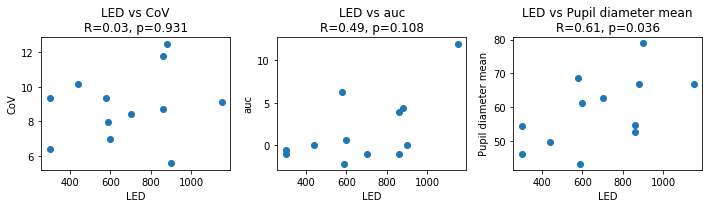

In [27]:
# Pairs of columns to compare
pairs = [
    ("CoV", "LED"),
    ("auc", "LED"),
    ("Pupil diameter mean", "LED")
]

fig, axes = plt.subplots(1, 3, figsize=(10,3))

for ax, (col2, col1) in zip(axes, pairs):
    # Scatter plot
    ax.scatter(merged[col1], merged[col2])
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    
    # Spearman correlation
    r, p = spearmanr(merged[col1], merged[col2])
    
    # Annotate at the top
    ax.set_title(f"{col1} vs {col2}\nR={r:.2f}, p={p:.3f}")

plt.tight_layout()
plt.show()


In [31]:
'LEDD on median {0} ({1} | {2})'.format(LED.LED.median(), LED.LED.quantile(0.25), LED.LED.quantile(0.75))

'LEDD on median 650.0 (545.0 | 865.0)'